In [1]:
# # 중기 매물(2·5번) — 최소 숙박을 줄여야 하는 근거
#
# 최소 숙박 4–29박인 `source == 0` 매물(2번 + 5번)이 **최소 숙박을 3박 이하로 낮춰야 하는지**를 수치로 확인합니다.
# 결과 해설은 [reports/MIDSTAY_MIN_NIGHTS.md](../reports/MIDSTAY_MIN_NIGHTS.md)에 있습니다.
#
# 순서: ① 대상 → ② 원자료 → ③ 같은 동급 그룹 안 비교 → ④ 같은 호스트 안 비교 (역인과 반론) → ⑤ 2번 — 팔리는데 왜 줄이나 → ⑥ 기대 효과 시나리오
#
# 쓰는 기법은 기술 통계 · 부호 검정 · **더미 변수를 넣은 선형회귀**입니다. 같은 호스트(또는 같은 동급 그룹)마다 더미를 넣어, 그 안에서만 비교한 효과를 봅니다(통계 용어로 '고정효과'). **모든 결과는 인과가 아니라 연관입니다.**

In [2]:
# [0-1] 라이브러리 & 데이터 — segmentation_2x3.ipynb 와 같은 정의
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if any(_f == f.name for f in mpl.font_manager.fontManager.ttflist):
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
C = {"main": "#4E79A7", "accent": "#F28E2B", "gray": "#9C9C9C"}

ROOT = Path.cwd()
while not (ROOT / "README.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
d = pd.read_parquet(ROOT / "data/processed/InsightStay_data_cleaned.parquet")

s = d[d["source"] == 0].copy()
s["stay"] = pd.cut(s["minimum_nights"], [0, 3, 29, np.inf], labels=["단기", "중기", "장기"]).astype(str)
s["cell"] = s["cell"].astype(int)
s["norev"] = (s["number_of_reviews_ltm"] == 0).astype(int)        # 최근 1년 거래 없음
s["mid"] = (s["stay"] == "중기").astype(int)
s["entire"] = (s["room_type"] == "Entire home/apt").astype(int)
s["lpr"] = np.log(s["price_rel"])                                   # 동급 대비 가격 (log)
s["a5"] = s["amenity_rel"] / 5                                      # 동급 대비 편의시설 (5개 단위)
BANDS = [0, 1, 2, 3, 4, 5, 7, 29]
BLAB = ["1박", "2박", "3박", "4박", "5박", "6–7박", "8–29박"]
s["band"] = pd.cut(s["minimum_nights"], BANDS + [np.inf], labels=BLAB + ["30박+"]).astype(str)
u = s[s["stay"] != "장기"].copy()                                   # 단기 + 중기 (1·2·4·5번)
print(f"source == 0: {len(s):,}행 · 단기+중기: {len(u):,}행")


def fe_lpm(df, y, xs, g):
    """그룹마다 더미를 넣은 선형회귀 (= 그룹 평균을 빼고 회귀, 결과는 같다).
    결과가 0/1이라 계수는 확률 차이(%p). 신뢰구간은 같은 그룹의 행을 한 덩어리로 보고 계산한다(군집 강건 표준오차)."""
    D = df[[y] + xs + [g]].dropna()
    dm = D[[y] + xs] - D.groupby(g)[[y] + xs].transform("mean")
    X, Y = dm[xs].to_numpy(float), dm[y].to_numpy(float)
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    e = Y - X @ b
    inv = np.linalg.inv(X.T @ X)
    G = pd.factorize(D[g])[0]
    S = np.zeros((G.max() + 1, len(xs)))
    np.add.at(S, G, X * e[:, None])
    se = np.sqrt(np.diag(inv @ (S.T @ S) @ inv))
    out = pd.DataFrame({"효과(%p)": b * 100, "95% 하한": (b - 1.96 * se) * 100, "95% 상한": (b + 1.96 * se) * 100}, index=xs)
    return out, len(D), D[g].nunique()

source == 0: 678,130행 · 단기+중기: 640,207행


## 1. 대상 — 중기 매물 2번 + 5번

In [3]:
# [1-1] 중기 매물의 규모와 최소 숙박 분포
mid = s[s["stay"] == "중기"]
print(f"중기 매물 {len(mid):,}건 (source == 0의 {len(mid) / len(s):.1%}) · 2번 {(mid.cell == 2).sum():,} · 5번 {(mid.cell == 5).sum():,}")
tab = pd.crosstab(mid["band"], mid["cell"]).reindex(BLAB[3:])
tab.columns = ["2번 (팔림)", "5번 (안 팔림)"]
tab["합계"] = tab.sum(axis=1)
tab["무거래율"] = tab["5번 (안 팔림)"] / tab["합계"]
tab

중기 매물 76,662건 (source == 0의 11.3%) · 2번 43,293 · 5번 33,369


,2번 (팔림),5번 (안 팔림),합계,무거래율
band,,,,
4박,17269,8576,25845,0.332
5박,11496,8508,20004,0.425
6–7박,9066,10185,19251,0.529
8–29박,5462,6100,11562,0.528


- 중기 매물은 **76,662건(`source == 0`의 11.3%)** 입니다. 2번(팔림) 43,293 · 5번(안 팔림) 33,369.
- 4박에서는 3분의 1이 안 팔리지만 **6박부터는 절반 이상이 안 팔립니다.**

## 2. 원자료 — 최소 숙박이 길수록 안 팔리고, 팔리던 매물도 더 끊긴다

In [4]:
# [2-1] 최소 숙박별 무거래율 · '팔리다 끊김' 비율 (누적 리뷰가 있는 매물 중 최근 1년 0건)
raw = u.groupby("band").agg(매물=("id", "size"), 무거래율=("norev", "mean"), 최근1년리뷰_중앙값=("number_of_reviews_ltm", "median")).reindex(BLAB)
ever = u[u["number_of_reviews"] > 0]
raw["과거 거래 매물"] = ever.groupby("band").size().reindex(BLAB)
raw["끊김 비율"] = ever.groupby("band")["norev"].mean().reindex(BLAB)
raw

,매물,무거래율,최근1년리뷰_중앙값,과거 거래 매물,끊김 비율
band,,,,,
1박,313768,0.275,4.000,257234,0.116
2박,171809,0.206,6.000,152934,0.107
3박,77968,0.295,3.000,64919,0.153
4박,25845,0.332,2.000,21168,0.184
5박,20004,0.425,1.000,15093,0.238
6–7박,19251,0.529,0.000,13029,0.304
8–29박,11562,0.528,0.000,7491,0.271


In [5]:
# [2-2] 단기 vs 중기 요약
summ = pd.DataFrame({
    "무거래율": u.groupby("stay")["norev"].mean(),
    "끊김 비율 (과거 거래 매물 중)": ever.groupby("stay")["norev"].mean(),
}).reindex(["단기", "중기"])
summ

,무거래율,끊김 비율 (과거 거래 매물 중)
stay,,
단기,0.257,0.118
중기,0.435,0.238


- **무거래율** — 1–3박은 21–30%로 평평하고 2박이 가장 낮습니다. 4박 33% → 5박 43% → 6–7박 53%로 계단처럼 오릅니다.
- **끊김 비율** — 과거에 팔렸던 매물 중 최근 1년 거래가 끊긴 비율도 2박 10.7% → 4박 18.4% → 6–7박 30.4%로 오릅니다. 중기는 23.8%로 단기(11.8%)의 **2배**입니다.
- 끊김 비율은 **지금 팔리는 2번에게 해당하는 위험**입니다. 2번이 계속 중기로 남으면 5번으로 넘어갈 가능성이 단기 매물의 2배라는 뜻입니다.

## 3. 같은 동급 그룹 안 비교 — 지역 · 방 타입 · 인원 차이가 아닌가

In [6]:
# [3-1] 동급 그룹(도시 × 방 타입 × 인원)마다 중기 vs 단기 — 무거래율 · 끊김 비율 (양쪽 30건 이상)
def peer_sign(df, v, min_n=30):
    g = df.groupby(["peer", "stay"])[v].agg(["mean", "size"]).unstack()
    g = g[(g[("size", "단기")] >= min_n) & (g[("size", "중기")] >= min_n)]
    diff = g[("mean", "중기")] - g[("mean", "단기")]
    k = int((diff > 0).sum())
    return len(diff), k, diff.median(), stats.binomtest(k, len(diff)).pvalue

for v, df_, name in [("norev", u, "무거래율"), ("norev", ever, "끊김 비율")]:
    n_, k, med, p = peer_sign(df_, v)
    print(f"{name}: 동급 그룹 {n_}개 중 중기가 더 높은 그룹 {k}개 ({k / n_:.0%}) · 차이 중앙값 +{med:.1%}p · 부호 검정 p = {p:.0e}")

무거래율: 동급 그룹 298개 중 중기가 더 높은 그룹 286개 (96%) · 차이 중앙값 +16.9%p · 부호 검정 p = 3e-69
끊김 비율: 동급 그룹 268개 중 중기가 더 높은 그룹 258개 (96%) · 차이 중앙값 +11.6%p · 부호 검정 p = 2e-63


In [7]:
# [3-2] 동급 그룹 더미를 넣은 선형회귀 — 가격 · 편의시설까지 맞추고 (신규 매물 제외)
base = u[~u["new_listing"] & u["price_rel"].notna() & u["amenity_rel"].notna()]
r1, n1, g1 = fe_lpm(base, "norev", ["mid", "lpr", "a5"], "peer")
r2, n2, g2 = fe_lpm(base[base["number_of_reviews"] > 0], "norev", ["mid", "lpr", "a5"], "peer")
print(f"무거래: {n1:,}건 · 동급 그룹 {g1}개 · 단기 기준 무거래율 {base.loc[base.mid == 0, 'norev'].mean():.1%}")
print(r1.round(1))
print(f"\n끊김: {n2:,}건 · 동급 그룹 {g2}개")
print(r2.round(1))

무거래: 585,601건 · 동급 그룹 653개 · 단기 기준 무거래율 21.5%
     효과(%p)  95% 하한  95% 상한
mid  18.400  16.900  19.800
lpr  15.100  14.100  16.100
a5   -3.200  -3.400  -3.100

끊김: 513,525건 · 동급 그룹 653개
     효과(%p)  95% 하한  95% 상한
mid  12.700  11.700  13.700
lpr   8.000   7.200   8.800
a5   -1.400  -1.500  -1.300


- **동급 그룹 298개 중 96%** 에서 중기가 더 안 팔리고, **268개 중 96%** 에서 중기가 더 많이 끊깁니다.
- 가격·편의시설까지 동급 안에서 맞추면 중기 설정은 무거래 확률을 **+18.4%p**(단기 21.5% 기준), 끊김 확률을 **+12.7%p** 올립니다.
- 여기까지는 [SEGMENTATION_2x3_VALIDATION.md](../reports/SEGMENTATION_2x3_VALIDATION.md) 2-5 · 3장과 같은 결론입니다(로지스틱 회귀 오즈비 2.63).

## 4. 같은 호스트 안 비교 — "의지 약한 호스트가 최소 숙박도 길게 건다"는 반론

In [8]:
# [4-1] 단기 매물과 중기 매물을 둘 다 가진 호스트 — 같은 사람의 매물끼리 비교
both = u.groupby("host_id")["mid"].agg(["min", "max"])
both = both[(both["min"] == 0) & (both["max"] == 1)].index
hu = u[u["host_id"].isin(both)]
hg = hu.groupby(["host_id", "stay"])["norev"].mean().unstack()
diff = hg["중기"] - hg["단기"]
k, j = int((diff > 0).sum()), int((diff < 0).sum())
print(f"호스트 {len(hg):,}명 · 매물 {len(hu):,}건 (단기 {(hu.mid == 0).sum():,} · 중기 {(hu.mid == 1).sum():,})")
print(f"호스트 평균 무거래율: 단기 매물 {hg['단기'].mean():.1%} vs 중기 매물 {hg['중기'].mean():.1%}")
print(f"중기가 더 안 팔린 호스트 {k:,}명 vs 단기가 더 안 팔린 호스트 {j:,}명 (같음 {int((diff == 0).sum()):,}명) "
      f"→ 차이가 난 호스트 중 {k / (k + j):.0%} · 부호 검정 p = {stats.binomtest(k, k + j).pvalue:.0e}")
hs = hu.groupby("host_id").size().reindex(hg.index)
for lo, hi, lab in [(2, 2, "2채"), (3, 5, "3–5채"), (6, 20, "6–20채"), (21, 10**6, "21채+")]:
    kk = diff[(hs >= lo) & (hs <= hi)]
    print(f"  {lab:6s} 호스트 {len(kk):5,}명 · 중기가 더 안 팔린 비율 {(kk > 0).sum() / (kk != 0).sum():.0%}")

호스트 9,105명 · 매물 77,094건 (단기 52,827 · 중기 24,267)
호스트 평균 무거래율: 단기 매물 26.7% vs 중기 매물 41.5%
중기가 더 안 팔린 호스트 3,094명 vs 단기가 더 안 팔린 호스트 1,445명 (같음 4,566명) → 차이가 난 호스트 중 68% · 부호 검정 p = 4e-135
  2채     호스트 3,700명 · 중기가 더 안 팔린 비율 72%
  3–5채   호스트 2,951명 · 중기가 더 안 팔린 비율 69%
  6–20채  호스트 1,773명 · 중기가 더 안 팔린 비율 66%
  21채+   호스트   681명 · 중기가 더 안 팔린 비율 63%


In [9]:
# [4-2] 호스트 더미를 넣은 선형회귀 — 같은 호스트 안에서 가격 · 편의시설 · 통집까지 맞추고 (신규 매물 제외)
hb = base[base["host_id"].isin(both)].copy()
r3, n3, g3 = fe_lpm(hb, "norev", ["mid", "lpr", "a5", "entire"], "host_id")
print(f"무거래 · 호스트 더미 회귀: {n3:,}건 · 호스트 {g3:,}명 · 단기 매물 무거래율 {hb.loc[hb.mid == 0, 'norev'].mean():.1%}")
print(r3.round(1))
hb["hp"] = hb["host_id"].astype(str) + "|" + hb["peer"].astype(str)
r4, n4, g4 = fe_lpm(hb, "norev", ["mid", "lpr", "a5"], "hp")
print(f"\n무거래 · 호스트 × 동급 그룹 더미 회귀 (같은 호스트의 같은 조건 매물끼리): {n4:,}건 · 묶음 {g4:,}개")
print(r4.round(1))
he = base[base["number_of_reviews"] > 0]
be = he.groupby("host_id")["mid"].agg(["min", "max"])
he = he[he["host_id"].isin(be[(be["min"] == 0) & (be["max"] == 1)].index)]
r5, n5, g5 = fe_lpm(he, "norev", ["mid", "lpr", "a5", "entire"], "host_id")
print(f"\n끊김 · 호스트 더미 회귀: {n5:,}건 · 호스트 {g5:,}명 · 단기 매물 끊김 비율 {he.loc[he.mid == 0, 'norev'].mean():.1%}")
print(r5.round(1))

무거래 · 호스트 더미 회귀: 73,078건 · 호스트 8,951명 · 단기 매물 무거래율 27.3%
        효과(%p)  95% 하한  95% 상한
mid     14.100  13.000  15.200
lpr      7.500   6.300   8.800
a5      -2.900  -3.200  -2.600
entire -11.400 -13.800  -8.900

무거래 · 호스트 × 동급 그룹 더미 회귀 (같은 호스트의 같은 조건 매물끼리): 73,078건 · 묶음 23,769개
     효과(%p)  95% 하한  95% 상한
mid  13.000  11.900  14.200
lpr   6.400   5.300   7.600
a5   -2.800  -3.100  -2.500

끊김 · 호스트 더미 회귀: 51,975건 · 호스트 6,707명 · 단기 매물 끊김 비율 11.3%
        효과(%p)  95% 하한  95% 상한
mid      8.000   7.100   8.900
lpr      3.300   2.300   4.300
a5      -0.900  -1.200  -0.600
entire  -5.000  -7.300  -2.700


In [10]:
# [4-3] 같은 호스트 안 용량-반응 — 2박 기준, 하루씩 늘릴 때 무거래 확률이 몇 %p 오르나
DOSE = {"1박": (1, 1), "3박": (3, 3), "4박": (4, 4), "5박": (5, 5), "6–7박": (6, 7), "8–29박": (8, 29)}
hd = hb.copy()
for k_, (lo, hi) in DOSE.items():
    hd[k_] = hd["minimum_nights"].between(lo, hi).astype(int)
dose, nd, gd = fe_lpm(hd, "norev", list(DOSE) + ["lpr", "a5", "entire"], "host_id")
dose = dose.loc[list(DOSE)]
dose.loc["2박"] = 0.0
dose = dose.reindex(BLAB)
dose["매물"] = [hd["minimum_nights"].between(*DOSE.get(b, (2, 2))).sum() for b in BLAB]
base2 = hd.loc[hd.minimum_nights == 2, "norev"].mean()
print(f"{nd:,}건 · 호스트 {gd:,}명 · 2박 매물 무거래율 {base2:.1%}")
display_dose = dose.round(1)
display_dose

73,078건 · 호스트 8,951명 · 2박 매물 무거래율 21.8%


,효과(%p),95% 하한,95% 상한,매물
1박,0.300,-1.100,1.600,19898
2박,0.000,0.000,0.000,16645
3박,5.000,3.600,6.300,13824
4박,9.700,8.100,11.300,8540
5박,14.400,12.700,16.000,5803
6–7박,21.200,19.000,23.300,4731
8–29박,29.800,27.000,32.500,3637


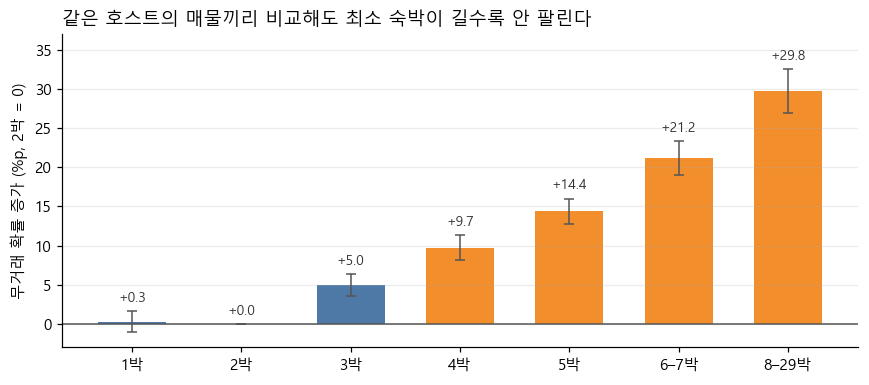

In [11]:
# [4-4] 그림 — 같은 호스트 안에서 최소 숙박별 무거래 확률 증가분
fig, ax = plt.subplots(figsize=(8, 3.6))
xs = np.arange(len(dose))
cols = [C["main"]] * 3 + [C["accent"]] * 4
ax.bar(xs, dose["효과(%p)"], color=cols, width=0.62)
ax.errorbar(xs, dose["효과(%p)"], yerr=[dose["효과(%p)"] - dose["95% 하한"], dose["95% 상한"] - dose["효과(%p)"]],
            fmt="none", ecolor="#555", elinewidth=1, capsize=3)
for i, (v, hi) in enumerate(zip(dose["효과(%p)"], dose["95% 상한"])):
    ax.text(i, max(hi, 0) + 0.8, f"{v:+.1f}", ha="center", va="bottom", fontsize=9, color="#333")
ax.axhline(0, color="#555", lw=1)
ax.set_xticks(xs, BLAB)
ax.set_ylabel("무거래 확률 증가 (%p, 2박 = 0)")
ax.set_ylim(-3, 37)
ax.set_title("같은 호스트의 매물끼리 비교해도 최소 숙박이 길수록 안 팔린다", loc="left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

**역인과 반론에 대한 답** — "활동 의지가 약한 호스트가 최소 숙박도 길게 잡는다"면, **같은 호스트의 매물끼리** 비교했을 때 차이가 사라져야 합니다. 사라지지 않습니다.
- 단기와 중기 매물을 둘 다 가진 **호스트 9,105명** 안에서 무거래율은 단기 26.7% vs 중기 41.5%이고, 차이가 난 호스트의 **68%** 에서 중기 쪽이 더 안 팔립니다. 2채만 가진 개인 호스트에서도 72%입니다.
- 같은 호스트 안에서 가격·편의시설·통집을 맞춘 **호스트 더미 회귀**에서도 중기 설정은 무거래 확률을 **+14.1%p**(단기 27.3% 기준) 올립니다. 같은 호스트의 **같은 동급 그룹 매물끼리**만 비교해도 +13.0%p입니다.
- **같은 호스트 안 용량-반응** — 2박 대비 3박 +5.0 → 4박 +9.7 → 5박 +14.4 → 6–7박 +21.2 → 8–29박 +29.8%p. 하루씩 늘릴수록 단조롭게 커집니다.
- 같은 호스트 안에서 **끊김 위험도 +8.0%p**(단기 11.3% 기준, 약 1.7배)입니다.

호스트의 의지·역량·운영 방식은 같은 호스트 안에서 일정하므로, 남은 차이는 호스트가 아니라 **매물 설정**에 붙어 있습니다. 인과를 증명한 것은 아니지만, 가장 강한 대안 설명을 데이터로 배제했습니다.

## 5. 2번 — 지금 팔리는데 왜 줄이나

In [12]:
# [5-1] 팔리는 매물(최근 1년 리뷰 1건+)끼리, 같은 동급 그룹 안에서 중기(2번) vs 단기(1번)
o = u[u["number_of_reviews_ltm"] > 0].copy()
o["nights"] = np.minimum(o["number_of_reviews_ltm"] / 0.5 * np.maximum(o["minimum_nights"], 3), 0.7 * 365)  # 손님 1팀 = 최소 숙박만큼 묵는다고 가정
o["revenue"] = o["nights"] * o["price"]
rows = []
for v, name in [("number_of_reviews_ltm", "예약 수 (최근 1년 리뷰)"), ("nights", "추정 숙박일"), ("revenue", "추정 연매출")]:
    g = o.groupby(["peer", "stay"])[v].agg(["median", "size"]).unstack()
    g = g[(g[("size", "단기")] >= 20) & (g[("size", "중기")] >= 20)]
    r = g[("median", "중기")] / g[("median", "단기")]
    ob = o.groupby("host_id")["mid"].agg(["min", "max"])
    oh = o[o["host_id"].isin(ob[(ob["min"] == 0) & (ob["max"] == 1)].index)]
    h = oh.groupby(["host_id", "stay"])[v].median().unstack()
    rh = h["중기"] / h["단기"]
    rows.append([name, len(g), r.median(), (r < 1).mean(), len(h), rh.median(), (rh < 1).mean()])
pd.DataFrame(rows, columns=["지표", "동급 그룹 수", "중기/단기 (동급 중앙값)", "중기가 낮은 그룹",
                            "호스트 수", "중기/단기 (같은 호스트)", "중기가 낮은 호스트"]).set_index("지표")

,동급 그룹 수,중기/단기 (동급 중앙값),중기가 낮은 그룹,호스트 수,중기/단기 (같은 호스트),중기가 낮은 호스트
지표,,,,,,
예약 수 (최근 1년 리뷰),285,0.400,0.940,5378,0.667,0.647
추정 숙박일,285,0.848,0.639,5378,1.111,0.440
추정 연매출,285,0.733,0.775,5378,1.097,0.449


In [13]:
# [5-2] 2번의 달력 — 열려 있는데 안 팔린 날이 있나
c12 = s[s["cell"].isin([1, 2])]
c12.groupby("cell").agg(매물=("id", "size"), 예약가능일_중앙값=("availability_365", "median"),
                        최근1년리뷰_중앙값=("number_of_reviews_ltm", "median"), 리뷰기반가동률_중앙값=("occ_review", "median"))

,매물,예약가능일_중앙값,최근1년리뷰_중앙값,리뷰기반가동률_중앙값
cell,,,,
1,418900,223.000,9.000,0.148
2,43293,181.000,4.000,0.110


**2번 — 결론**
- **예약 수는 확실히 적습니다.** 같은 동급 그룹에서 단기의 0.40배(그룹 94%), 같은 호스트 안에서도 0.67배입니다.
- **매출은 단정할 수 없습니다.** 손님이 최소 숙박만큼 묵는다고 가정하면 동급 그룹 기준 0.73배지만 같은 호스트 안에서는 1.10배입니다. "2번은 지금 손해를 보고 있다"는 주장은 하지 않습니다.
- **그래서 2번의 근거는 매출이 아니라 위험과 기회입니다.**
  - 위험 — 끊김 위험이 단기의 2배(동급 그룹 96%, 같은 호스트 +8.0%p). 2번은 5번으로 넘어가는 길목입니다.
  - 기회 — 2번은 예약 가능일이 181일 열려 있는데 예약은 1번의 절반 이하입니다. **최소 숙박은 하한일 뿐이라 낮춰도 주 단위 손님은 그대로 받을 수 있고**, 빈 날짜에 1–3박 손님이 더해집니다.
- 처방 강도는 5번보다 약하게 둡니다 — 성수기 주 단위 운영은 유지하고 **비수기 · 빈 날짜에 3박 이하를 허용**하도록 권합니다.

## 6. 기대 효과 시나리오

In [14]:
# [6-1] 시나리오 입력값 — 팔리는 매물의 추정 연매출 (1박 가격 × 리뷰 기반 가동률 × 365)
s["rev_year"] = s["price"] * s["occ_review"] * 365
sold = s[s["number_of_reviews_ltm"] > 0]
q = sold[sold.cell == 2]["rev_year"].quantile([.25, .5])
OFF = s.loc[s["quote_peak"].eq(False), "price_rel"].median() / s.loc[s["quote_peak"].eq(True), "price_rel"].median()
print(f"2번 추정 연매출 25% {q.iloc[0]:,.0f}€ · 중앙값 {q.iloc[1]:,.0f}€ (성수기 가격 기준)")
print(f"비성수기 견적의 동급 대비 가격 ÷ 성수기 = {OFF:.2f} → 연평균 가격 보정 계수로 사용")

2번 추정 연매출 25% 3,401€ · 중앙값 7,489€ (성수기 가격 기준)
비성수기 견적의 동급 대비 가격 ÷ 성수기 = 0.85 → 연평균 가격 보정 계수로 사용


In [15]:
# [6-2] 5번 — 3박 이하로 낮추면 새로 팔리기 시작할 매물 수 (같은 호스트 안 용량-반응을 그대로 적용)
gain = (dose["효과(%p)"] - dose.loc["3박", "효과(%p)"]) / 100          # 현재 구간 → 3박으로 낮출 때 무거래 확률 감소
c5 = s[(s["cell"] == 5) & ~s["new_listing"]].copy()
c5["gain"] = c5["band"].map(gain).fillna(0)
print(f"5번 (신규 매물 제외) {len(c5):,}건 · 3박으로 낮출 때 평균 판매 확률 증가 {c5.gain.mean():.1%}p → 기대 전환 {c5.gain.sum():,.0f}건 (전원 참여 시)")
rows = []
for adopt in [0.3, 0.5, 1.0]:
    conv = c5["gain"].sum() * adopt
    for lab, rev in [("보수 (2번 하위 25%)", q.iloc[0]), ("기준 (2번 중앙값)", q.iloc[1])]:
        rows.append([f"{adopt:.0%}", lab, conv, conv * rev * OFF * 0.155])
sc5 = pd.DataFrame(rows, columns=["호스트 참여율", "전환 매물 1건 매출", "새로 팔리는 매물", "연 수수료(€)"])
sc5.round(0)

5번 (신규 매물 제외) 29,659건 · 3박으로 낮출 때 평균 판매 확률 증가 13.1%p → 기대 전환 3,882건 (전원 참여 시)


,호스트 참여율,전환 매물 1건 매출,새로 팔리는 매물,연 수수료(€)
0,30%,보수 (2번 하위 25%),"1,165.000","519,684.000"
1,30%,기준 (2번 중앙값),"1,165.000","1,144,345.000"
2,50%,보수 (2번 하위 25%),"1,941.000","866,139.000"
3,50%,기준 (2번 중앙값),"1,941.000","1,907,241.000"
4,100%,보수 (2번 하위 25%),"3,882.000","1,732,279.000"
5,100%,기준 (2번 중앙값),"3,882.000","3,814,482.000"


In [16]:
# [6-3] 2번 — 끊김 위험을 단기 수준으로 낮추면 지키는 수수료 (같은 호스트 안 끊김 차이 적용)
c2 = s[s["cell"] == 2]
fee2 = (c2["rev_year"] * OFF * 0.155).sum()
lapse_gap = r5.loc["mid", "효과(%p)"] / 100
print(f"2번 {len(c2):,}건 · 연 수수료 합계(보정) {fee2:,.0f}€")
print(f"같은 호스트 안 중기 끊김 위험 +{lapse_gap:.1%}p → 지키는 수수료 {fee2 * lapse_gap:,.0f}€ (전원 참여) · "
      f"{fee2 * lapse_gap * 0.5:,.0f}€ (50%) · {fee2 * lapse_gap * 0.3:,.0f}€ (30%)")

2번 43,293건 · 연 수수료 합계(보정) 72,946,069€
같은 호스트 안 중기 끊김 위험 +8.0%p → 지키는 수수료 5,849,867€ (전원 참여) · 2,924,933€ (50%) · 1,754,960€ (30%)


**기대 효과 — 시나리오 (가정에 기댄 추정)**
- **5번:** 같은 호스트 안 용량-반응을 그대로 적용하면, 3박으로 낮출 때 5번(신규 매물 제외 29,659건)의 판매 확률이 평균 **13.1%p** 오릅니다 → 전원 참여 시 **약 3,900건이 새로 팔림.** 연 수수료는 참여율 30–100%, 전환 매물 1건 매출을 2번 하위 25%–중앙값으로 두면 **약 0.5–3.8백만 €** 입니다.
- **2번:** 2번이 만드는 연 수수료는 약 7,300만 €입니다(추정). 끊김 위험 차이 8.0%p를 단기 수준으로 낮추면 **약 1.8–5.8백만 €** 를 지키는 셈입니다. 끊김 비율은 1년 단위가 아니라 누적 비율이라 이 값은 **위험 노출 규모**로만 읽습니다.
- 공통 가정 — 매출 = 1박 가격 × 리뷰 기반 가동률 × 365 × 0.85(비성수기 보정) · 수수료 15.5%. 연관을 인과처럼 적용한 상한이므로 발표에서는 **범위**로만 제시합니다.